In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report, roc_auc_score, roc_curve)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import joblib
import os

print("✅ Libraries imported!")
print("TensorFlow version:", tf.__version__)

✅ Libraries imported!
TensorFlow version: 2.21.0


In [2]:
X_train = pd.read_csv('../data/processed/X_train_final.csv')
X_val   = pd.read_csv('../data/processed/X_val.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train_final.csv').values.ravel()
y_val   = pd.read_csv('../data/processed/y_val.csv').values.ravel()
y_test  = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print("✅ Data loaded!")
print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

✅ Data loaded!
X_train shape: (107748, 41)
X_val shape:   (26938, 41)
X_test shape:  (22544, 41)


In [3]:
model = keras.Sequential([
    # Input layer
    layers.Input(shape=(41,)),
    
    # Hidden layer 1
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Hidden layer 2
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Hidden layer 3
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    
    # Output layer
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           5,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,513 (64.50 KB)

 Trainable params: 16,129 (63.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Stop training if no improvement after 5 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("⏳ Training DNN... (may take 3-5 minutes)")

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=512,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

print("✅ DNN trained!")

⏳ Training DNN... (may take 3-5 minutes)
Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9378 - loss: 0.1726 - val_accuracy: 0.9745 - val_loss: 0.0827
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9724 - loss: 0.0755 - val_accuracy: 0.9848 - val_loss: 0.0420
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9806 - loss: 0.0527 - val_accuracy: 0.9874 - val_loss: 0.0339
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9840 - loss: 0.0441 - val_accuracy: 0.9893 - val_loss: 0.0306
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9856 - loss: 0.0400 - val_accuracy: 0.9919 - val_loss: 0.0277
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9870 - loss: 0.0369 - val_accuracy: 0.9915 - val_loss: 0.0255
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9881 - loss: 0.0332 - val_accuracy: 0.9901 - val_loss: 0.0280
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - a

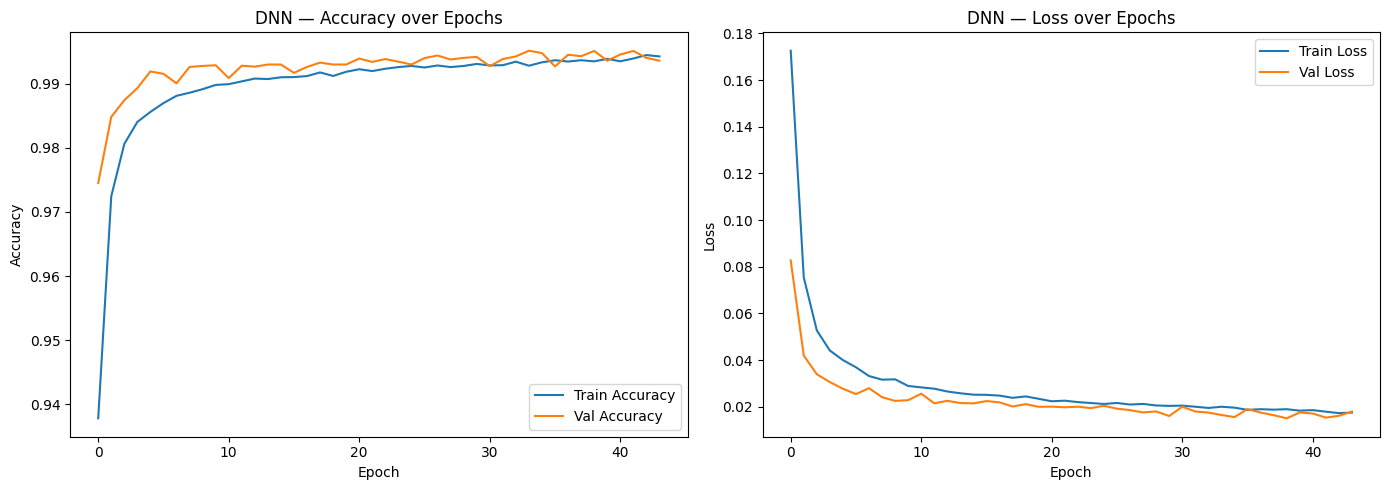

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('DNN — Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss plot
ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('DNN — Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig('../docs/dnn_training_history.png')
plt.show()

In [6]:
y_prob = model.predict(X_val).ravel()
y_pred = (y_prob > 0.5).astype(int)

print("=" * 45)
print("           DNN RESULTS")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_val, y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_val, y_pred)*100:.2f}%")
print(f"Recall:    {recall_score(y_val, y_pred)*100:.2f}%")
print(f"F1-Score:  {f1_score(y_val, y_pred)*100:.2f}%")
print(f"AUC-ROC:   {roc_auc_score(y_val, y_prob)*100:.2f}%")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Normal', 'Anomaly']))

842/842 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
           DNN RESULTS
Accuracy:  99.51%
Precision: 99.63%
Recall:    99.39%
F1-Score:  99.51%
AUC-ROC:   99.98%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     13469
     Anomaly       1.00      0.99      1.00     13469

    accuracy                           1.00     26938
   macro avg       1.00      1.00      1.00     26938
weighted avg       1.00      1.00      1.00     26938



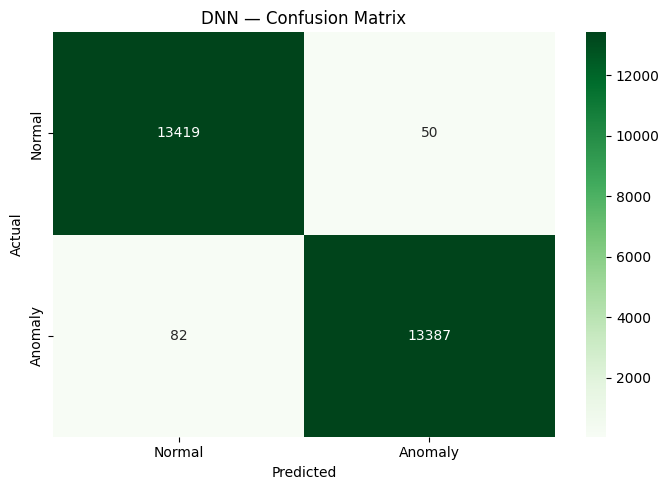


False Positive Rate: 0.37%


In [7]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('DNN — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../docs/dnn_confusion_matrix.png')
plt.show()

FP  = cm[0][1]
TN  = cm[0][0]
FPR = FP / (FP + TN) * 100
print(f"\nFalse Positive Rate: {FPR:.2f}%")

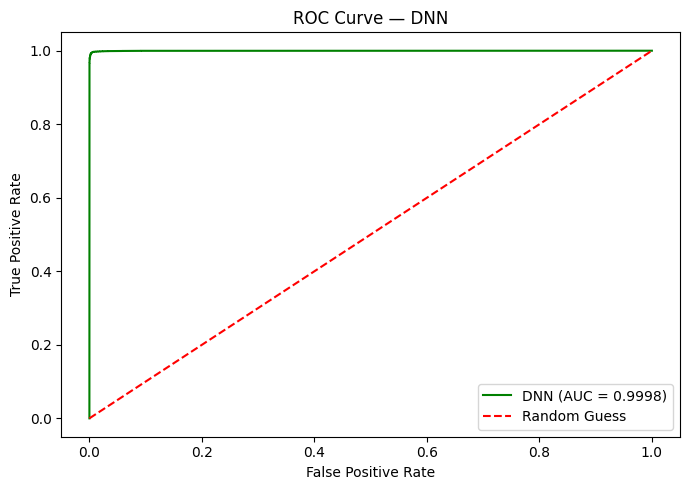

In [8]:
fpr, tpr, _ = roc_curve(y_val, y_prob)
auc_score   = roc_auc_score(y_val, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='green', label=f'DNN (AUC = {auc_score:.4f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Guess')
plt.title('ROC Curve — DNN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('../docs/dnn_roc_curve.png')
plt.show()

In [9]:
os.makedirs('../models', exist_ok=True)
model.save('../models/dnn_model.h5')
print("✅ DNN model saved to models/dnn_model.h5")

✅ DNN model saved to models/dnn_model.h5


In [10]:
# Save in newer keras format
model.save('../models/dnn_model.keras')
print("✅ DNN model saved in new format too!")

✅ DNN model saved in new format too!
